In [1]:
import matplotlib.pyplot as plt
import numpy as np
import glob, torch, pickle, utils, model, copy, matplotlib, utils
from tqdm import trange

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = [6.0, 4.0]
"""
Created Mar 16 2020; Reviewed Aug 5, 2020
"""
name = '1L_MSE_GD_eta_sigs0p2_sigw0p8_reps'
utils.process_raw_data(name, skip_fails=True)
dataset = utils.find_and_load_data(name, attribute='sig_w')

print('baseline eta:', dataset[0]['args'].eta * np.linalg.norm(dataset[0]['a'][0]))



Number of entries: 30
#0     1L_MSE_GD_eta_sigs0p2_sigw0p8_reps

 Loaded dataset: *** 1L_MSE_GD_eta_sigs0p2_sigw0p8_reps ***, 
 created 2021-03-18 17:44:16.286828 

#    |N    |L    |error  |DelW1  |#entries|sig_w
0    |1000 |1    |0.1586 |5109.3657 |21     |0.8  
1    |1000 |1    |0.1584 |253.4018 |27     |0.8  
2    |1000 |1    |0.1596 |0.1562 |9      |0.8  
3    |1000 |1    |0.1572 |10.4721 |16     |0.8  
4    |1000 |1    |0.1594 |0.1536 |8      |0.8  
5    |1000 |1    |0.1584 |0.8634 |24     |0.8  
6    |1000 |1    |0.1584 |4705.7939 |12     |0.8  
7    |1000 |1    |0.1587 |102.6045 |8      |0.8  
8    |1000 |1    |0.1598 |3.8343 |49     |0.8  
9    |1000 |1    |0.1595 |0.1580 |10     |0.8  
10   |1000 |1    |0.1584 |330.6229 |7      |0.8  
11   |1000 |1    |0.1589 |1.0510 |48     |0.8  
12   |1000 |1    |0.1601 |222.9846 |10     |0.8  
13   |1000 |1    |0.1597 |1.0222 |36     |0.8  
14   |1000 |1    |0.1580 |6.6586 |20     |0.8  
15   |1000 |1    |0.1583 |173.6042 |27     |0.8  
1

## TEMP error

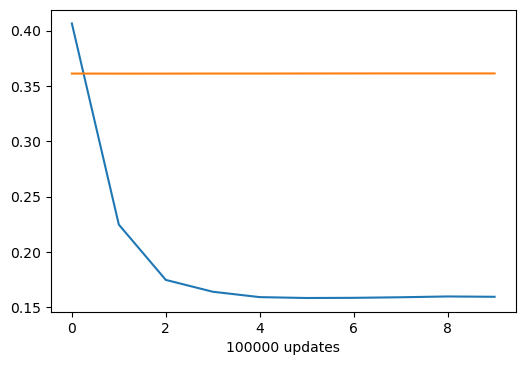

In [16]:
plt.figure()
plt.plot(dataset[4]['error'])
plt.plot(dataset[4]['sigs_error'])
plt.xlabel(f'{dataset[4]["args"].test_interval} updates')
plt.savefig('figures/raw/sigs_transfer.svg')

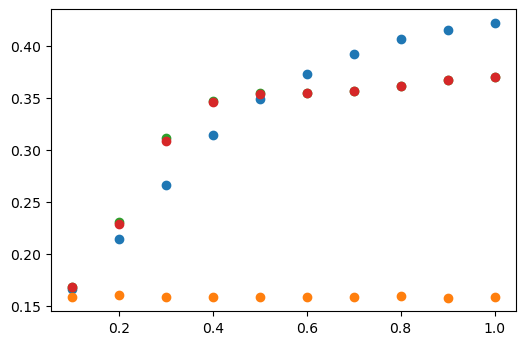

In [14]:
sigw = [data['args'].sig_w for data in dataset]
init_theta_error = [data['error'][0] for data in dataset]
final_theta_error = [data['error'][-1] for data in dataset]
init_sigs_error = [data['sigs_error'][0] for data in dataset]
final_sigs_error = [data['sigs_error'][-1] for data in dataset]

plt.figure()
plt.scatter(sigw, init_theta_error)
plt.scatter(sigw, final_theta_error)
plt.scatter(sigw, init_sigs_error)
plt.scatter(sigw, final_sigs_error)

## Norm of weight changes vs. parameter

Text(0, 0.5, 'delw1 norm')

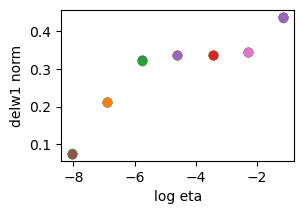

In [88]:
plt.figure()
for data in dataset:
    plt.scatter(np.log(data['args'].eta * np.linalg.norm(data['a'][-1])), np.linalg.norm(data['delW'][0][-1]['s']))
# plt.ylim(0, 1)
plt.xlabel('log eta')
plt.ylabel('delw1 norm')

In [33]:
# Collect datasets that have converged

all_etas = [data['args'].eta for data in dataset]
unique_etas = np.unique(all_etas)
unique_etas = unique_etas[:-1]
etas = [[] for i in unique_etas]


for data in dataset:
    if data['error'][-1] > 0.5:
        continue
    else:
        for i in range(len(unique_etas)):
            if data['args'].eta == unique_etas[i]:
                etas[i].append(data)

delw1 = np.zeros((2, 6))
delw2 = np.zeros((2, 6))
delw3 = np.zeros((2, 6))
tot = np.zeros((2, 6))
for i in range(6):
    delw1_data = np.array([np.linalg.norm(d['delW'][0][-1]['s']) for d in etas[i]])
    delw1[0, i] = np.mean(delw1_data)
    delw1[1, i] = np.std(delw1_data) / np.sqrt(len(delw1_data))
    delw2_data = np.array([np.linalg.norm(d['delW'][1][-1]['s']) for d in etas[i]])
    delw2[0, i] = np.mean(delw2_data)
    delw2[1, i] = np.std(delw2_data) / np.sqrt(len(delw2_data))
    delw3_data = np.array([np.linalg.norm(d['delW'][2][-1]['s']) for d in etas[i]])
    delw3[0, i] = np.mean(delw3_data)
    delw3[1, i] = np.std(delw3_data) / np.sqrt(len(delw3_data))
    tot_data = delw1_data + delw2_data + delw3_data
    tot[0, i] = np.mean(tot_data)
    tot[1, i] = np.std(tot_data) / np.sqrt(len(tot_data))



Text(0, 0.5, 'changes to weights')

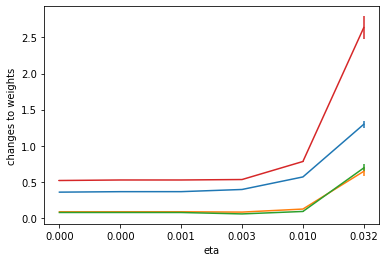

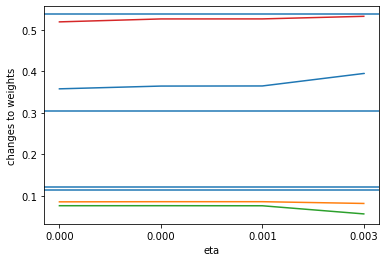

In [88]:
xticks = [f'{d:.3f}' for d in unique_etas * np.linalg.norm(data['a'][-1])]
plt.figure()
plt.errorbar(range(6), delw1[0], delw1[1])
plt.errorbar(range(6), delw2[0], delw2[1])
plt.errorbar(range(6), delw3[0], delw3[1])
plt.errorbar(range(6), tot[0], tot[1])
plt.xticks(range(6), xticks)
# plt.ylim(0, 1)
plt.xlabel('eta')
plt.ylabel('changes to weights')

plt.figure()
plt.errorbar(range(4), delw1[0][:4], delw1[1][:4]); plt.axhline(0.304)
plt.errorbar(range(4), delw2[0][:4], delw2[1][:4]); plt.axhline(0.122)
plt.errorbar(range(4), delw3[0][:4], delw3[1][:4]); plt.axhline(0.115)
plt.errorbar(range(4), tot[0][:4], tot[1][:4]); plt.axhline(0.3+0.122+0.115)
plt.xticks(range(4), xticks[:4])
# plt.ylim(0, 1)
plt.xlabel('eta')
plt.ylabel('changes to weights')
# plt.savefig('figures/raw/delw_over_eta.svg')

## Make descriptive plots of the dynamics

Text(0.5, 1.0, 'delW norm')

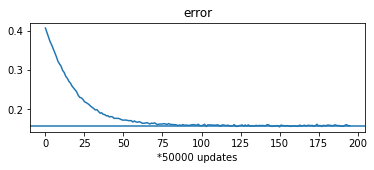

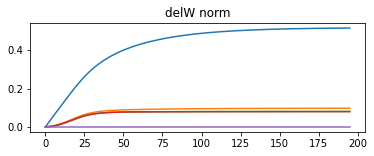

In [10]:
data = dataset[4]
stimuli = train_utils.GaborStimuli(data['args'], simple_mode=True, verbose=False)
bl_net = model.Model(data['args'])
plt.figure(figsize=(6, 2))
plt.plot(data['error'])
plt.xlabel(f'*{data["args"].test_interval} updates')
plt.axhline(stimuli.mld_err)
plt.title('error')
# plt.savefig('figures/raw/3l_error_sigs0p2_sigw0p8.svg')

plt.figure(figsize=(6, 2))
for i in range(len(data['delW'])):
    plt.plot([np.linalg.norm(w['s']) / np.linalg.norm(bl_net.Ws[i]) for w in data['delW'][i]])
plt.plot(utils.get_changes(data['a']))
plt.title('delW norm')
# plt.savefig('figures/raw/3l_delw_sigs0p2_sigw0p8.svg')

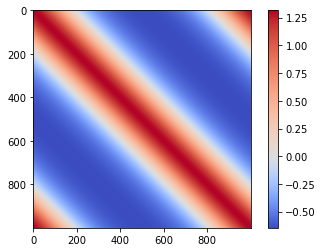

In [4]:
import matplotlib.colors as colors
divnorm = colors.TwoSlopeNorm(vcenter=0)
plt.figure()
plt.imshow(bl_net.Ws[0] * data['args'].N, cmap='coolwarm', norm=divnorm)
plt.colorbar()
# plt.savefig('figures/raw/W10.svg')

In [95]:
data['delW'][0][-1]['s'][0]**2

0.12981446109296613

<BarContainer object of 1 artists>

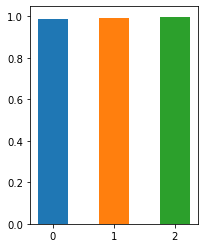

In [113]:
plt.figure(figsize=(3, 4))
plt.bar(0, data['delW'][0][-1]['s'][0]**2 / np.sum(data['delW'][0][-1]['s']**2), width=0.5)
plt.bar(1, data['delW'][1][-1]['s'][0]**2 / np.sum(data['delW'][1][-1]['s']**2), width=0.5)
plt.bar(2, data['delW'][2][-1]['s'][0]**2 / np.sum(data['delW'][2][-1]['s']**2), width=0.5)

# plt.savefig('figures/raw/L3_all_w_sing_val.svg')



<BarContainer object of 3 artists>

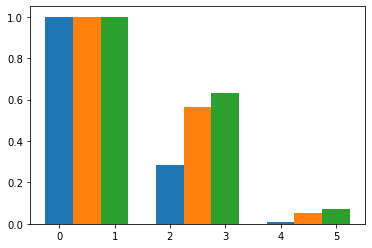

In [7]:
plt.figure()
plt.bar(np.arange(3) * 2, data['delW'][0][-1]['s'] / data['delW'][0][-1]['s'][0], width=0.5)
plt.bar(np.arange(3) * 2 + 0.5, data['delW'][1][-1]['s'] / data['delW'][1][-1]['s'][0], width=0.5)
plt.bar(np.arange(3) * 2 + 1, data['delW'][2][-1]['s'] / data['delW'][2][-1]['s'][0], width=0.5)

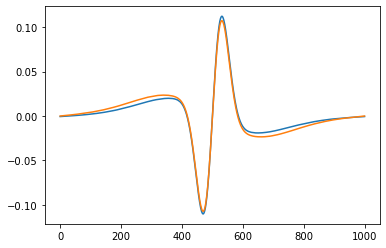

In [5]:
plt.figure()
plt.plot(data['delW'][0][-1]['v'][0])
plt.plot(utils.normalize(data['v_eff'][-1] - data['v_eff'][0]))
# plt.savefig('figures/raw/l3_delw1_right_vec.svg')

In [41]:
data.keys()

dict_keys(['loss', 'error', 'a', 'v_eff', 'x1', 'theta1', 'theta2', 'phi_prime', 'delW', 'args', '_time', 'errors_with_original_readouts', 'errors_with_new_readouts'])

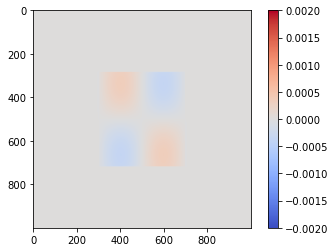

In [67]:
plt.figure()
plt.imshow(utils.recover_matrix(data['delW'][1][-1]), cmap='coolwarm', vmin=-0.002, vmax=0.002)
plt.colorbar()
plt.savefig('figures/raw/L3_delw2.svg')

# u, s, v = np.linalg.svd(utils.recover_matrix(data['delW'][0][-1]))

# delv = utils.normalize(data['v_eff'][-1] - data['v_eff'][0])
# plt.figure()
# plt.plot(data['delW'][0][-1]['v'][0])
# plt.plot(delv * -1)
# plt.savefig('figures/raw/L1_right_vector.svg')

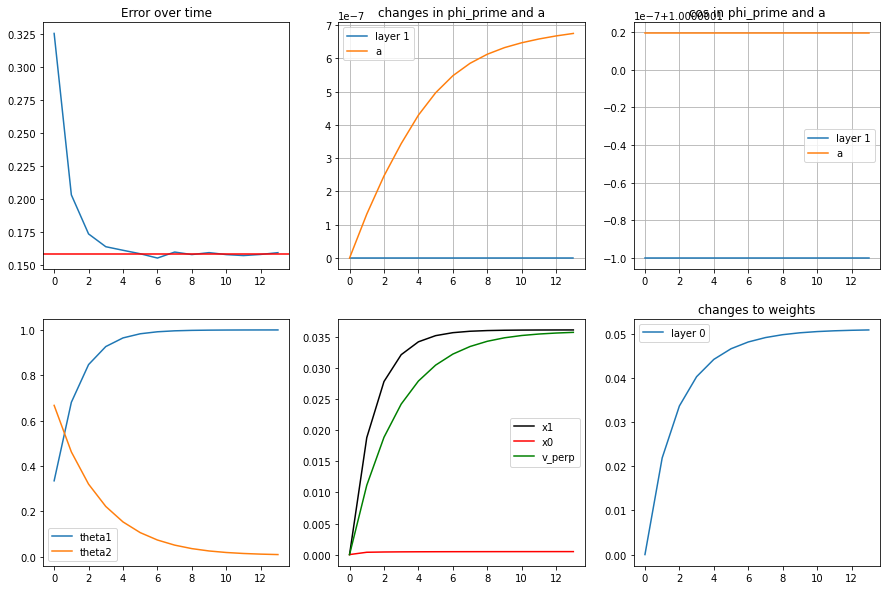

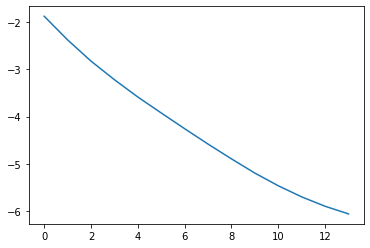

In [6]:

#%%
"""Make some descriptive plots for a particular trial"""

def summary_fig(data_dict):
    glance_fig = plt.figure(figsize=(15, 10))

    glance_fig.add_subplot(231)
    plt.plot(data_dict['error'])
    plt.axhline(stimuli.mld_err, color='r')
    plt.title('Error over time')

    glance_fig.add_subplot(232)
    for i, _phi_prime in enumerate(data_dict['phi_prime']):
        plt.plot(utils.get_changes(_phi_prime), label=f'layer {i+1}')
    plt.plot(utils.get_changes(data_dict['a']), label='a')
    plt.legend(); plt.grid(); plt.title('changes in phi_prime and a')

    glance_fig.add_subplot(233)
    for i, _phi_prime in enumerate(data_dict['phi_prime']):
        plt.plot(utils.get_cos(_phi_prime), label=f'layer {i+1}')

    plt.plot(utils.get_cos(data_dict['a']), label='a')
    plt.legend(); plt.grid(); plt.title('cos in phi_prime and a')

    glance_fig.add_subplot(234)
    plt.plot(data_dict['theta1'], label='theta1'); plt.plot(data_dict['theta2'], label='theta2'); plt.legend()

    glance_fig.add_subplot(235)

    x1_comp = []; x0_comp = []; perp_comp = []
    for delw in data_dict['delW'][0]:
        _mat = utils.recover_matrix(delw)
        x1_comp.append(np.linalg.norm(_mat @ stimuli.x1_normed.t().numpy()))
        x0_comp.append(np.linalg.norm(_mat @ stimuli.x0_normed.t().numpy()))
        perp_comp.append(np.sqrt(np.sum(_mat**2) - x1_comp[-1]**2 - x0_comp[-1]**2))

    plt.plot(x1_comp, color='k', label='x1')
    plt.plot(x0_comp, color='r', label='x0')
    plt.plot(perp_comp, color='g', label='v_perp')
    plt.legend()

    glance_fig.add_subplot(236)
    for i in range(data_dict['args'].n_layers):
        changes_to_weights = [np.linalg.norm(utils.recover_matrix(delw)) for delw in data_dict['delW'][i]]
        plt.plot(changes_to_weights, label=f'layer {i}')
    plt.legend(); plt.title('changes to weights')

    plt.figure()
    plt.plot(np.log10(data_dict['loss']))

data = dataset[4]

# recreate corresponding stimuli and network
stimuli = train_utils.GaborStimuli(data['args'], simple_mode=True, verbose=False)
net = model.Model(data['args'])

summary_fig(data)

## Compare $|\Delta W|$ norms across parameters

In [26]:
data['args']

Namespace(BATCH_NAME='3L_MSE_GD_sigsP2_sigwP8_etap05_reps', N=1000, Nhid=1000, TRIAL_IND=18, _duration=2285.3120856285095, cluster=1, eta=0.001567808911204338, f=None, lambda2=0.0, loss='MSE', n_layers=3, n_learn=8000000, n_test_trials=2500, n_train_trials=25, noise_var=0.01, nonlinearity='relu', sig_s=0.2, sig_w=0.8, test_interval=100000, theta=3.141592653589793)

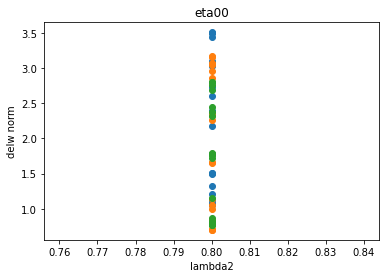

In [23]:
data_param_list = [data['args'].sig_w for data in dataset]
delw1_norm = [np.linalg.norm(utils.recover_matrix(data['delW'][0][-1])) for data in dataset]
delw2_norm = [np.linalg.norm(utils.recover_matrix(data['delW'][1][-1])) for data in dataset]
plt.figure()
plt.xlabel('lambda2')
plt.ylabel('delw norm')
plt.scatter(data_param_list, delw1_norm)
plt.scatter(data_param_list, delw2_norm)
plt.title('eta00')

try:
    delw3_norm = [np.linalg.norm(utils.recover_matrix(data['delW'][2][-1])) for data in dataset]
    plt.scatter(data_param_list, delw3_norm)
except:
    None

Text(0.5, 0, 'lambda2')

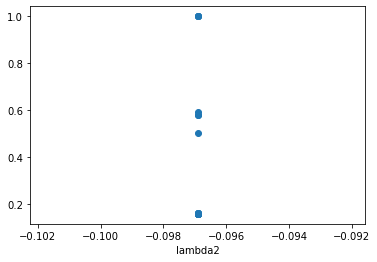

In [24]:
plt.figure()
data_final_loss = []
data_lambda = []
for _data in dataset:
    data_lambda.append(_data['args'].sig_w)
    data_final_loss.append((_data['error'][-1]))
    # data_final_loss.append((_data['loss'][-1]))
    # data_final_loss.append(np.log10(_data['loss'][-1]))

plt.scatter(np.log10(data_lambda),data_final_loss); plt.xlabel('lambda2')

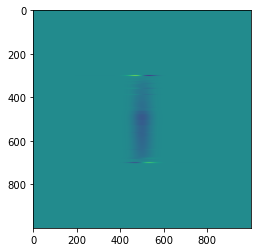

In [45]:
mean_weights = np.zeros_like(utils.recover_matrix(dataset[0]['delW'][0][-1]))

for _data in dataset:
    if _data['error'][-1] > 0.16:
        continue
    else:
        mean_weights += utils.recover_matrix(_data['delW'][0][-1])

plt.figure()
plt.imshow(mean_weights)

100%|██████████| 128/128 [00:02<00:00, 48.95it/s]


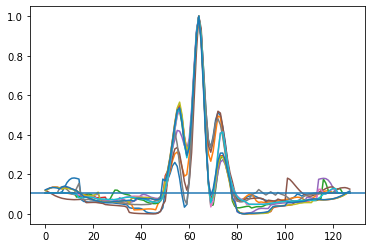

In [42]:
plt.figure()
args2 = copy.copy(dataset[0]['args'])
probe_angles = np.linspace(0, 2*np.pi, 128, endpoint=False)
bl_net = model.Model(args2)


for _data in dataset:
    if _data['error'][-1] > 0.16:
        continue
    trained_net = model.Model(args2)
    utils.load_GD_changes(trained_net, _data)

    J = np.zeros(len(probe_angles))
    for i in trange(len(probe_angles)):
        args2.theta = probe_angles[i]
        
        probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
        
        J[i] = r_utils.get_mean_field_fi(trained_net, probe_stim)

    plt.plot(J)

plt.axhline(r_utils.get_mean_field_fi(bl_net, probe_stim))

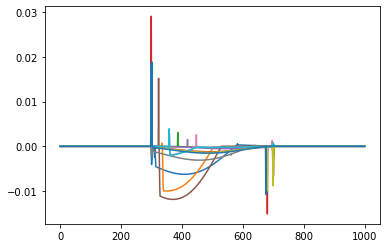

In [49]:
plt.figure()
for _data in dataset:
    if _data['error'][-1] > 0.16:
        continue
    plt.plot(utils.recover_matrix(_data['delW'][1][-1])[300])

In [ ]:
plt.figure()
args2 = copy.copy(dataset[0]['args'])
probe_angles = np.linspace(0, 2*np.pi, 128, endpoint=False)
bl_net = model.Model(args2)


for _data in dataset:
    if _data['error'][-1] > 0.16:
        continue
    trained_net = model.Model(args2)
    utils.load_GD_changes(trained_net, _data)

    J = np.zeros(len(probe_angles))
    for i in trange(len(probe_angles)):
        args2.theta = probe_angles[i]
        
        probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
        
        J[i] = r_utils.get_mean_field_fi(trained_net, probe_stim)

    plt.plot(J)

plt.axhline(r_utils.get_mean_field_fi(bl_net, probe_stim))

In [ ]:


#%% PLOTRO Plot readout

sim_ind = 4

plt.figure()
plt.plot(dataset[sim_ind]['a'][-1])

np.linalg.norm(dataset[sim_ind]['a'][-1])

print(dataset[sim_ind]['args'])
#%% PLTDELW Plot DelW
data = dataset[0]
layer_ind = 0
time_ind = -1  # index of checkpoints taken during training. -1 means final weights
plt.figure()
plt.imshow(utils.recover_matrix(data['delW'][layer_ind][time_ind]) * data['args'].N, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.colorbar()
# plt.savefig('figures/raw/3l_sgd_delw3.svg')


#%%
plt.figure()
plt.plot(data['phi_prime'][0][0])
plt.plot(data['phi_prime'][0][-1])

np.linalg.norm(data['phi_prime'][0][-1] - data['phi_prime'][0][0]) / np.linalg.norm(data['phi_prime'][0][1])

#%% Initial a norms
plt.figure()
plt.scatter([_data['args'].sig_w for _data in dataset], [(np.linalg.norm(_data['a'][-1] - _data['a'][0])) / np.linalg.norm(_data['a'][0]) for _data in dataset])




#%% Compare loss / error across parameters

# plt.plot(np.log10(_data['loss'])); plt.axhline(-4)
#%% Compare dela ratios across parameters
data_param_list = [data['args'].sig_w for data in dataset]
dela_norm = [np.linalg.norm(data['a'][-1] - data['a'][0]) / np.linalg.norm(data['a'][0]) for data in dataset]
# delw2_norm = [np.linalg.norm(utils.recover_matrix(data['delW'][1][-1])) for data in dataset]
plt.figure()
plt.xlabel('sig_w')
plt.ylabel('Dela Ratio')
plt.scatter(data_param_list, dela_norm)
# plt.scatter(data_param_list, delw2_norm)

#%% Compare singular value ratios across parameters
plt.figure()
for data in dataset:
    delw = data['delW'][0][-1]
    plt.scatter(data['args'].N, delw['s'][1] / delw['s'][0])
plt.ylabel('2nd sing val / 1st sing val')
plt.xlabel('N')
plt.title('sigs=0.2, si')


#%% Compare dela
data_p = []
dela = []

for data in dataset:
    data_p.append(data['args'].sig_w)
    dela.append(np.linalg.norm(data['a'][-1] - data['a'][0]) / np.linalg.norm(data['a'][0]))

plt.figure()
plt.scatter(data_p, dela)

#%% temp: delW2
plt.figure()
plt.imshow(utils.recover_matrix(data['delW'][1][-1]), cmap='coolwarm')
plt.
#%%
""" Only works for results including subsampling hidden neurons (will throw an error otherwise)"""
colors = ['k', 'gray']
plt.figure(dpi=100)
for i in range(2):
    sampling_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    pre_training_infos = np.zeros_like(sampling_ratios)
    post_training_infos = np.zeros_like(sampling_ratios)
    for _data in dataset:
        pre_training_infos[sampling_ratios.index(_data['args'].sampling_ratio)] += utils.error_to_fi(_data['pre_training_subsampled_error'])
        post_training_infos[sampling_ratios.index(_data['args'].sampling_ratio)] += utils.error_to_fi(_data['post_training_subsampled_error'])

    full_info = utils.error_to_fi(train_utils.GaborStimuli(data['args'], verbose=False, simple_mode=True).mld_err)

    plt.plot(np.array(sampling_ratios)*_data['args'].Nhid, pre_training_infos / 20 / full_info, marker='o', label=f'before, M={_data["args"].Nhid}', ls='--', color=colors[i])
    plt.plot(np.array(sampling_ratios)*_data['args'].Nhid, post_training_infos / 20 / full_info, marker='o', label=f'after, M={_data["args"].Nhid}', color=colors[i])
    # plt.axhline(, label='full info', color='k')
    plt.xlabel('Number of neurons sampled'); plt.legend()
    plt.ylabel('Linear Fisher info \n (frac. of total info in input)')
    plt.title(f"N={dataset[0]['args'].N}")

#%%
"""Will ONLY work for results where different combinations of rank-1 components are added"""
comp_index = [0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18]

transfer_metric = np.zeros((9, 9))
v_eff_angle = np.zeros((9, 9))

for _data in dataset:
    _stim = train_utils.GaborStimuli(_data['args'], simple_mode=True, verbose=False)
    transfer_metric[comp_index.index(_data['args'].x1_comp), comp_index.index(_data['args'].perp_comp)] = _data['errors_with_new_readouts'].max()
    v_eff_angle[comp_index.index(_data['args'].x1_comp), comp_index.index(_data['args'].perp_comp)] = utils.cos(_data['v_eff'][-1], _stim.x1_normed)

plt.figure()
plt.imshow(transfer_metric)
plt.xlabel('v_perp component')
plt.ylabel('x1 component')
plt.colorbar()

plt.figure()
plt.imshow(v_eff_angle, vmin=0.99)
plt.xlabel('v_perp component')
plt.ylabel('x1 component')
plt.colorbar()
#%%
"""Will ONLY work for results where different combinations of rank-1 components are added"""
"""Plot with a fixed amount"""
plt.figure()
for _data in dataset:
    if _data['args'].perp_comp == 0.10 and _data['args'].x1_comp == 0.02:
        plt.plot(np.roll(_data['errors_with_new_readouts'], 0), label=_data['args'].x1_comp)
    if _data['args'].perp_comp == 0.08 and _data['args'].x1_comp == 0.18:
        plt.plot(np.roll(_data['errors_with_new_readouts'], 0), label=_data['args'].x1_comp)

plt.legend(['all perp', 'mostly x0'])
plt.axhline(0.110); plt.xlabel('Stimulus'); plt.ylabel('Error fraction')

#%%
"""Plot changes to weights across parameters"""
param_name = 'N'
w_norm_list = []
param_list = []
a_norm_list = []
for data in dataset:
    param_list.append(vars(data['args'])[param_name])
    w_norm_list.append(np.linalg.norm(utils.recover_matrix(data['delW'][0][-1])))
    a_norm_list.append(np.linalg.norm(data['a'][-1]))



plt.figure()
# ax = utils.sort_plot(param_list, w_norm_list, log=True)

plt.figure()
plt.plot(np.log(np.sort(param_list))[:-1], np.log(np.array(w_norm_list)[np.argsort(param_list)])[:-1])
plt.xlabel('log' + param_name); plt.ylabel('log a norm')

#%% Plot transfer results

plt.figure()
for data in dataset:
    plt.plot(data['errors_with_new_readouts'])



#%%
def compile_transfer_data(dataset:list, index:str):
    error_w_original_readout = {}
    error_w_new_readout = {}
    mld_dict = {}
    baseline_dict = {}
    for _data in dataset:
        stim = train_utils.GaborStimuli(_data['args'], simple_mode=True, verbose=False)
        mld_dict[str(vars(_data['args'])[index])] = stim.mld_err
        baseline_dict[str(vars(_data['args'])[index])] = _data['error'][0]

        if str(_data['args'].noise_var) in error_w_original_readout.keys():
            error_w_new_readout[str(vars(_data['args'])[index])] += _data['errors_with_new_readouts']
            error_w_original_readout[str(vars(_data['args'])[index])] += np.roll(_data['errors_with_original_readouts'], int(len(_data['errors_with_original_readouts']) / 2))
        else:
            error_w_new_readout[str(vars(_data['args'])[index])] = _data['errors_with_new_readouts'].copy()
            error_w_original_readout[str(vars(_data['args'])[index])] = np.roll(_data['errors_with_original_readouts'], int(len(_data['errors_with_original_readouts']) / 2)).copy()

    return error_w_original_readout, error_w_new_readout, mld_dict, baseline_dict

error_w_original_readout, error_w_new_readout, mld_dict, baseline_dict = compile_transfer_data(dataset, 'sig_w')

plt.figure()
for key in error_w_new_readout:
    if key=='0.1' or key=='0.5':
        plt.plot(np.linspace(0, 2*np.pi, 32), error_w_new_readout[key] / 5, label=key, color=key)
        plt.axhline(mld_dict[key], color=key, ls='--')
        plt.axhline(baseline_dict[key], color=key, ls=':')
plt.title('errors with new readouts'); plt.legend(); plt.xlabel('Stimulus')

plt.figure()
for key in error_w_original_readout:
    if key=='0.1' or key=='0.5':
        plt.plot(np.linspace(0, 2*np.pi, 100), error_w_original_readout[key] / 5, label='noise='+key, color=key)
        plt.axhline(mld_dict[key], color=key, ls='--')
        plt.axhline(baseline_dict[key], color=key, ls=':')
plt.title('errors with original readouts'); plt.legend(); plt.xlabel('Stimulus')

#%%
"""Specificity curves for errors with new readouts"""
plt.figure()

for key in error_w_new_readout:
    if key in ['0.1', '0.5']:
        info_after_learning = utils.error_to_fi(error_w_new_readout[key] / 5)
        baseline_info = utils.error_to_fi(baseline_dict[key])
        plt.plot(np.linspace(0, 2*np.pi, 32), (info_after_learning.max() - info_after_learning) / (info_after_learning.max() - baseline_info), label=key, color=key)
plt.title('Specificity with new readouts'); plt.legend(); plt.xlabel('Stimulus')

plt.figure()
for key in error_w_original_readout:
    if key in ['0.1', '0.5']:
        info_after_learning = utils.error_to_fi(error_w_original_readout[key] / 5)
        baseline_info = utils.error_to_fi(baseline_dict[key])
        plt.plot(np.linspace(0, 2*np.pi, 100), (info_after_learning.max() - info_after_learning) / (info_after_learning.max() - baseline_info), label=key, color=key)
plt.title('Specificity with original readouts'); plt.legend(); plt.xlabel('Stimulus')



#%%
plt.figure()
for _data in dataset:
    plt.scatter(_data['args'].Nhid, utils.error_to_fi(_data['error'][0]), color='k')
    plt.scatter(_data['args'].Nhid, utils.error_to_fi(_data['error'][-1]), color='r')
plt.axhline(utils.error_to_fi(stimuli.mld_err), color='r')
#%%
plt.figure()
for _data in dataset:
    x_axis = _data['args'].noise_var
    # plt.scatter(_data['args'].Nhid, np.linalg.norm(_data['delW'][0][-1]['s']) / np.sqrt(_data['args'].Nhid), color='k')
    simple_stim = train_utils.GaborStimuli(_data['args'], simple_mode=True, verbose=False)
    delw = utils.recover_matrix(_data['delW'][0][-1])
    x0_comp = np.linalg.norm(delw @ simple_stim.x0_normed.numpy().T)
    x1_comp = np.linalg.norm(delw @ simple_stim.x1_normed.numpy().T)
    # plt.scatter(_data['args'].Nhid, np.linalg.norm(_data['delW'][0][-1]['s']) / np.sqrt(_data['args'].Nhid), color='k')
    # plt.scatter(_data['args'].Nhid, x0_comp / np.linalg.norm(delw), color='k')
    plt.scatter(x_axis, x1_comp, color='k')
    plt.scatter(x_axis, x0_comp, color='r')
    plt.scatter(x_axis, np.sqrt(np.sum(delw**2) - x1_comp**2 - x0_comp**2), color='g')

    # plt.scatter(x_axis, x_axis * np.linalg.norm(_data['a'][0]))

# plt.figure()
# for _data in dataset:
#     # plt.scatter(_data['args'].Nhid, np.linalg.norm(_data['a'][-1]), color='k')
#     simple_stim = train_utils.GaborStimuli(_data['args'], simple_mode=True)
#     plt.scatter(_data['args'].Nhid, utils.cos(simple_stim.x1_normed, _data['v_eff'][0]))

#%%
"""Some comparisons between different trial"""

plt.figure()
for data in dataset:
    plt.scatter(np.log(data['args'].N), np.log(utils.get_changes(data['phi_prime'][0])[-1]), color='r')
    # plt.scatter(data['args'].n_layers, np.linalg.norm(data['delW'][0][-1]['s']))
plt.figure()

for data in dataset:
    plt.scatter(np.log(data['args'].N), np.linalg.norm(data['a'][-1]), color='r')

plt.figure()
for data in dataset:
    plt.scatter(data['args'].N, np.linalg.norm(data['delW'][0][-1]['s']), color='r')

#%%
plt.figure()
plt.plot(dataset[1]['a'][-1])
#%%
"""Why do phiprime vectors change?"""
#release memory
obs_to_layer = 3
data['args'].n_test_trials = 10000
stimuli = train_utils.GaborStimuli(data['args'])

net.RESET_WEIGHTS()
mean_input = torch.from_numpy(utils.make_x0(np.pi, data['args'].sig_s, data['args'].N).T).float()

obs_pre = net.get_obs(mean_input, to_layer=obs_to_layer)

phi_prime_pre = get_phiprime(net, data['args'], to_layer=obs_to_layer-1)


load_GD_changes(net, data, time_index=-1, skip=[])

obs_post = net.get_obs(mean_input, to_layer=obs_to_layer)
phi_prime_post = get_phiprime(net, data['args'], to_layer=obs_to_layer-1)

plt.figure()
plt.plot(obs_pre.T)
plt.plot(obs_post.T)

plt.figure()
plt.plot(phi_prime_pre)
plt.plot(phi_prime_post)

#%%
fixed_phi_prime = [[l[0]] for l in data['phi_prime']]
net.RESET_WEIGHTS()
stimuli = train_utils.GaborStimuli(data['args'])
utils.load_GD_changes(net, data, time_index=-1, skip=[])
v_eff_alter = get_v_eff(net, data['phi_prime'], data['a'], -1)
v_eff_alter2 = get_v_eff(net, fixed_phi_prime, data['a'], -1)


plt.figure()
plt.plot(v_eff_alter / np.linalg.norm(v_eff_alter))
plt.plot(v_eff_alter2 / np.linalg.norm(v_eff_alter2))
# plt.plot(data['v_eff'][-1] / np.linalg.norm(data['v_eff'][-1]))
plt.plot(stimuli.x1_normed.t())
# plt.plot(data['v_eff'][-1])


#%%


#%%
"""How much does phi_prime change during learning?"""
phiprime_fig = plt.figure()
phiprime_fig.add_subplot(221)
plt.plot(data['phi_prime'][0][0])
plt.plot(data['phi_prime'][0][-1]); plt.grid()

phiprime_fig.add_subplot(222)
plt.plot(data['phi_prime'][-1][0])
plt.plot(data['phi_prime'][-1][-1]); plt.grid()

#%%
net.RESET_WEIGHTS()
load_GD_changes(net, data, time_index=-1)

W_tilde = net.Ws[1] @ net.Ws[0]

v = data['a'][0] @ net.Ws[2]

# u, s, v = np.linalg.svd(W_tilde)

v_change = W_tilde @ W_tilde.T @ v.T
plt.figure()
plt.plot(v_change)
plt.plot(W_tilde @ mean_input.numpy().T)

print(phi_prime_pre[1].numpy() @ W_tilde @ W_tilde.T @ v_change)


#%%
"""Alternative measure"""
net.RESET_WEIGHTS()
mean_input = torch.from_numpy(utils.make_x0(np.pi, data['args'].sig_s, data['args'].N).T).float()

phi_prime_pre = [net.get_obs(mean_input, to_layer=i) for i in range(net.n_layers)]

for W, delW_list in zip(net.Ws, data['delW']):
    W += utils.recover_matrix(delW_list[-1])


phi_prime_post = [net.get_obs(mean_input, to_layer=i) for i in range(net.n_layers)]

plt.figure()
plt.plot(phi_prime_pre[-1].T)
plt.plot(phi_prime_post[-1].T)


#%%
"""
Gather response matrices
Each is of dimension n_points * n_dim
"""


to_layer = 1

def get_response_mats(network:model.Model, to_layer, stim_width, stim_dim, n_samples=200):
    probe_stimuli = torch.tensor([utils.make_x0(test_theta, stim_width, stim_dim).flatten() for test_theta in np.linspace(0, 2*np.pi, n_samples, endpoint=False)]).float()
    return network.get_obs(probe_stimuli, to_layer).numpy()


response_matrices = []
net.RESET_WEIGHTS()
# response_matrices.append(get_response_mats(network=net,
#                                            to_layer=to_layer,
#                                            stim_width=data['args'].sig_s,
#                                            stim_dim=data['args'].N))

utils.load_GD_changes(net, data, time_index=int(len(data['phi_prime'][0]) / 4))
response_matrices.append(get_response_mats(network=net,
                                           to_layer=to_layer,
                                           stim_width=data['args'].sig_s,
                                           stim_dim=data['args'].N))

utils.load_GD_changes(net, data, time_index=int(len(data['phi_prime'][0]) / 2))
response_matrices.append(get_response_mats(network=net,
                                           to_layer=to_layer,
                                           stim_width=data['args'].sig_s,
                                           stim_dim=data['args'].N))

utils.load_GD_changes(net, data, time_index=-1)
response_matrices.append(get_response_mats(network=net,
                                           to_layer=to_layer,
                                           stim_width=data['args'].sig_s,
                                           stim_dim=data['args'].N))

net.RESET_WEIGHTS()
ref_response_mat = get_response_mats(network=net, to_layer=to_layer, stim_width=data['args'].sig_s, stim_dim=data['args'].N)

ref_response_matrices = [ref_response_mat for i in range(len(response_matrices))]

colors=['0.8', '0.5', '0.2']
#%%
"""Compare changes across layers (EITHER RUN THE LAST CELL OR THIS ONE, NOT BOTH)"""
response_matrices = []
load_GD_changes(net, data, time_index=-1)
for i in range(data['args'].n_layers):
    response_matrices.append(get_response_mats(network=net,
                                               to_layer=i+1,
                                               stim_width=data['args'].sig_s,
                                               stim_dim=data['args'].N))

ref_response_matrices = []
net.RESET_WEIGHTS()
for i in range(data['args'].n_layers):
    ref_response_matrices.append(get_response_mats(network=net,
                                               to_layer=i+1,
                                               stim_width=data['args'].sig_s,
                                               stim_dim=data['args'].N))
#%%
"""Plot representations"""
rep_fig = plt.figure(figsize=(12, 6))

rep_fig.add_subplot(231); plt.title('Preferred orientation')
counts = []
for res_mat, color in zip(response_matrices, colors):
    counts = np.histogram(np.argmax(res_mat, axis=0), bins=np.linspace(0.5, 199.5, 51))[0]
    plt.plot(counts, color=color)

rep_fig.add_subplot(232); plt.title('peak response for each neuron \n (fraction of pre-learning levels)')
for ref_res_mat, res_mat, color in zip(ref_response_matrices, response_matrices, colors):
    plt.plot(np.max(res_mat, axis=0) / np.max(ref_res_mat, axis=0), color=color)

rep_fig.add_subplot(233); plt.title('mean response for each angle \n (fraction of pre-learning levels)')
for ref_res_mat, res_mat, color in zip(ref_response_matrices, response_matrices, colors):
    plt.plot(np.mean(res_mat, axis=1) / np.mean(ref_res_mat, axis=1), color=color)

rep_fig.add_subplot(234);plt.title('Width of tuning (fraction of pre-learning levels)')
for ref_res_mat, res_mat, color in zip(ref_response_matrices, response_matrices, colors):
    plt.plot(np.mean(res_mat, axis=0) / np.max(res_mat, axis=0) / (np.mean(ref_res_mat, axis=0) / np.max(ref_res_mat, axis=0)), color=color)

rep_fig.add_subplot(235); plt.title('Tuning curve slope at trained stim')
for ref_res_mat, res_mat, color in zip(ref_response_matrices, response_matrices, colors):
    plt.plot(np.abs(res_mat[101, :] - res_mat[99, :]) / (1e-2 + np.abs( + ref_res_mat[101, :] - ref_res_mat[99, :])), color=color)

rep_fig.add_subplot(236); plt.title('Single neuron Fano Factor')
# plt.axvline(np.mean(np.linalg.norm(W0 - np.mean(W0), axis=1)**2 / np.max(response_mat, axis=0)), color='k')
# plt.hist(np.linalg.norm(W0 + DelW - np.mean(W0 + DelW), axis=1)**2 / np.max(response_mat_after, axis=0), alpha=0.5, bins=np.linspace(0.005, 0.015, 15))

for ax in list(rep_fig.axes):
    plt.sca(ax)
    plt.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.85)
# plt.suptitle('Different lines represent different timepoints in training!!')



#%%
"""Which layer changes first"""
delW_norms = [[] for l in range(data['args'].n_layers)]

for t in range(len(data['delW'][0])):
    for norm_list, delw in zip(delW_norms, data['delW']):
        norm_list.append(np.linalg.norm(delw[t]['s']))

plt.figure()
for i, norm_list in enumerate(delW_norms):
    plt.plot(norm_list, label=f'layer{i+1}', marker='o')
plt.legend(); plt.title('$ || \Delta W^{(l)} || $', fontsize=20)
plt.xlabel('t'); plt.grid()

#%%
"""How the correlation structure changes after training"""

def get_corr_func(network:model.Model, data:dict, to_layer:int, stimuli:train_utils.GaborStimuli):
    covar1 = np.cov(network.get_obs(stimuli.tr_stim(), to_layer=to_layer).numpy().T)

    corr_func = np.zeros(data['args'].Nhid)
    for i in range(data['args'].Nhid):
        corr_func += 1 / data['args'].Nhid * np.roll(covar1[i], -i + int(network.dims[to_layer] / 2))
    return corr_func, covar1


full_stim = train_utils.GaborStimuli(data['args'], verbose=False)

net.RESET_WEIGHTS()
corr_func_before, covar_before = get_corr_func(net, data, 1, full_stim)
utils.load_GD_changes(net, data, -1, [])
corr_func_after, covar_after = get_corr_func(net, data, 1, full_stim)

plt.figure()
plt.plot(corr_func_before, label='before')
plt.plot(corr_func_after, label='after')
plt.axhline(0, color='k', ls='--')

#%%

def covar_to_corr_coef(covar_mat):
    mat_size = covar_mat.shape[0]
    corr_coef_mat = covar_mat / np.sqrt(np.diag(covar_mat).reshape(-1, 1) @ np.diag(covar_mat).reshape(1, -1) + 1e-9)
    corr_func = np.zeros(mat_size)
    for i in range(mat_size):
        corr_func += 1 / mat_size * np.roll(corr_coef_mat[i], -i + int(mat_size / 2))
    corr_func = (corr_func[int(mat_size / 2):] + corr_func[:int(mat_size / 2)][::-1]) / 2
    return corr_func, corr_coef_mat


corr_func_init, corr_mat_init = covar_to_corr_coef(covar_before)
corr_func_final, corr_mat_final = covar_to_corr_coef(covar_after)

plt.figure(dpi=100)
plt.plot(np.linspace(0, np.pi, len(corr_func_init)), corr_func_init, label='naive')
plt.plot(np.linspace(0, np.pi, len(corr_func_final)), corr_func_final, label='trained')
plt.axhline(0, color='k', ls='--')
plt.ylabel('average corr coef')
plt.xlabel('difference between preferred stimuli'); plt.legend()
plt.title(f'N={data["args"].N}, M={data["args"].Nhid}')

#%%
seq = np.linspace(1, -1, 100)
seq - np.roll(seq, 1)

#%%
"""
Look at how noise and signal changes over different angles
The idea is that linear FI for different angles changed after learning. J=F'Sigma^-1 F'. So which part changed?
"""
probe_angles = np.linspace(0, 2*np.pi, 32, endpoint=False)
signal_power = np.zeros(probe_angles.shape); noise_power = np.zeros(probe_angles.shape)
projected_noise = np.zeros(probe_angles.shape)

utils.load_GD_changes(net, data, time_index=-1)

for i, angle in enumerate(probe_angles):
    _temp_args = copy.copy(data['args'])
    _temp_args.theta = angle
    _temp_stim = train_utils.GaborStimuli(_temp_args, verbose=False)

    with torch.no_grad():
        obs = net.get_obs(_temp_stim.tr_stim()).numpy()

    sig_vec = ((obs[:_temp_args.n_train_trials].mean(0) - obs[_temp_args.n_train_trials:].mean(0)) / (2 / np.sqrt(_temp_args.N)))
    covar = np.cov(obs[:_temp_args.n_train_trials].T)

    signal_power[i] = np.sum(sig_vec**2)

    noise_power[i] = np.trace(covar)

    sig_vec_normed = sig_vec / np.linalg.norm(sig_vec)
    projected_noise[i] = sig_vec_normed.reshape(1, -1) @ covar @ sig_vec_normed.reshape(-1, 1)

#%%
"""Get baseline"""
net.RESET_WEIGHTS()
bl_sig_vec = ((obs[:_temp_args.n_train_trials].mean(0) - obs[_temp_args.n_train_trials:].mean(0)) / (2 / np.sqrt(_temp_args.N)))
bl_covar = np.cov(obs[:_temp_args.n_train_trials].T)

bl_sig_power = np.sum(bl_sig_vec**2)

bl_noise_power = np.trace(bl_covar)

sig_vec_normed = bl_sig_vec / np.linalg.norm(bl_sig_vec)
bl_projected_noise = sig_vec_normed.reshape(1, -1) @ bl_covar @ sig_vec_normed.reshape(-1, 1)

plt.figure()
plt.plot(signal_power / bl_sig_power)
plt.plot(noise_power / bl_noise_power)

plt.figure()
plt.plot(projected_noise / noise_power)
plt.axhline(1, color='k', ls='--')

#%%
plt.figure()
plt.imshow(utils.recover_matrix(data['delW'][0][-1]))

# plt.plot(data['a'][-1])


# 2. Single-run Analysis

## Error and delW norms over time

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in true_divide
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in true_divide
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in true_divide


Text(0.5, 1.0, '$|| \\Delta W^l(t) || / || \\Delta W^1(t) ||$')

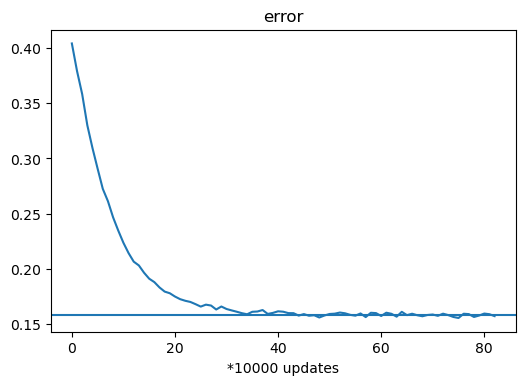

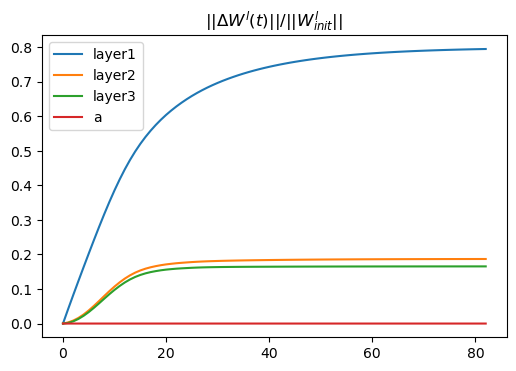

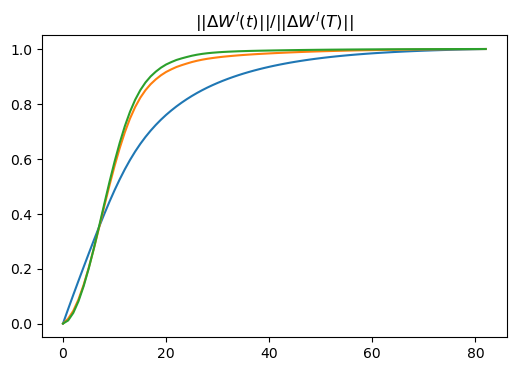

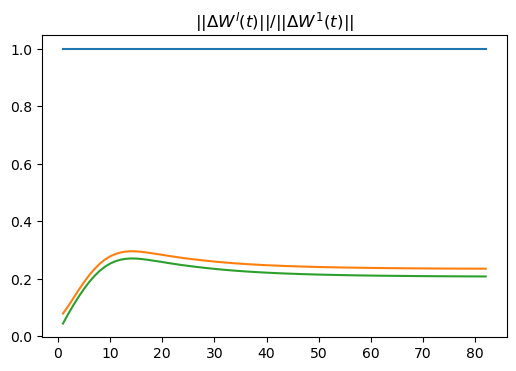

In [97]:
data = dataset[1]
stimuli = train_utils.GaborStimuli(data['args'], simple_mode=True, verbose=False)
bl_net = model.Model(data['args'])

plt.figure()
plt.plot(data['error'])
plt.xlabel(f'*{data["args"].test_interval} updates')
plt.axhline(stimuli.mld_err)
plt.title('error')
# plt.savefig('figures/raw/3l_error_sigs0p2_sigw0p8.svg')

delw_norms = [[np.linalg.norm(w['s']) / np.linalg.norm(bl_net.Ws[i]) for w in data['delW'][i]] for i in range(len(data['delW']))]

plt.figure()
for i in range(bl_net.n_layers):
    plt.plot(delw_norms[i] / np.linalg.norm(bl_net.Ws[i]), label='layer'+str(i+1))
plt.plot(utils.get_changes(data['a']), label='a')
plt.title(r'$|| \Delta W^l(t) || / || W^l_{init} ||$')
plt.legend()


plt.figure()
for i in range(bl_net.n_layers):
    plt.plot(delw_norms[i] / delw_norms[i][-1], label='layer'+str(i+1))
plt.title(r'$|| \Delta W^l(t) || / || \Delta W^l(T) ||$')


plt.figure()
for i in range(bl_net.n_layers):
    plt.plot(np.array(delw_norms[i]) / np.array(delw_norms[0]))
plt.title(r'$|| \Delta W^l(t) || / || \Delta W^1(t) ||$')

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log
  """
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log
  """
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log
  """
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log
  """
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log
  """
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log
  """


Text(0.5, 1.0, '$|| \\Delta W^l(t) || / || \\Delta W^l(T) ||$')

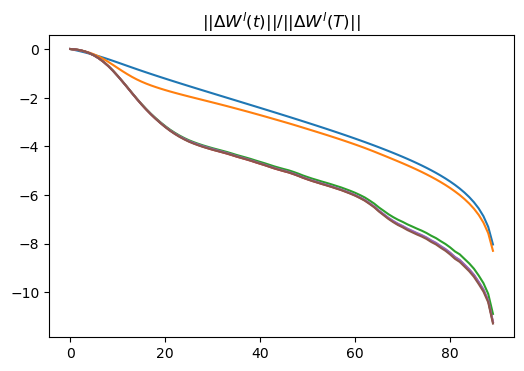

In [95]:
inverted = [1 - delw_norms[i] / delw_norms[i][-1] for i in range(net.n_layers)]

plt.figure()
for i in range(bl_net.n_layers):
    plt.plot(np.log(inverted)[i], label='layer'+str(i+1))
plt.title(r'$|| \Delta W^l(t) || / || \Delta W^l(T) ||$')

In [24]:
# create a Model object for loading weight changes; create a Stimuli object for testing
net = model.Model(data['args'])
stim = train_utils.GaborStimuli(data['args'], simple_mode=False, verbose=False)
xp = stim.x0 + stim.x1
xm = stim.x0 - stim.x1

# number of time points to sample
n_sample = 50
stride = int(len(data['loss']) / n_sample)

fi_curves = np.zeros((net.n_layers, n_sample))
grad_norms = np.zeros((net.n_layers, n_sample))
a_grad_norms = np.zeros(n_sample)
sampled_loss = np.zeros(n_sample)
signal_norms = np.zeros((net.n_layers, n_sample))
delw_norms = np.zeros((net.n_layers, n_sample))

for i in trange(n_sample):
    sampled_loss[i] = data['loss'][stride * i]
    
    # load weight changes
    net.RESET_WEIGHTS()
    for j in range(net.n_layers):
        net.Ws[j] += utils.recover_matrix(data['delW'][j][stride * i])
        delw_norms[j, i] = np.linalg.norm(data['delW'][j][stride * i]['s'])
    
    # calculate linear FI for trained stimuli at every layer
    for j in range(net.n_layers):
        fi_curves[j, i] = r_utils.get_mean_field_fi(net, stim, to_layer=j+1)
        signal_norms[j, i] = np.linalg.norm(net.get_obs(xp, to_layer=j+1).data.numpy() - net.get_obs(xm, to_layer=j+1).data.numpy())
    
    # calculate gradient norms
    net.RO.weight.data = torch.from_numpy(data['a'][stride * i]).float().t()
    train_utils.zero_and_grad(net, stim, 'MSE', v_teacher=stim.x1 * 10)
    a_grad_norms[i] = np.linalg.norm(net.RO.weight.grad.data.numpy())
    for j in range(net.n_layers):
        grad_norms[j, i] = np.linalg.norm(net.Ls[j].weight.grad.data.numpy())
        

100%|██████████| 50/50 [00:24<00:00,  2.07it/s]


## Gradient norms

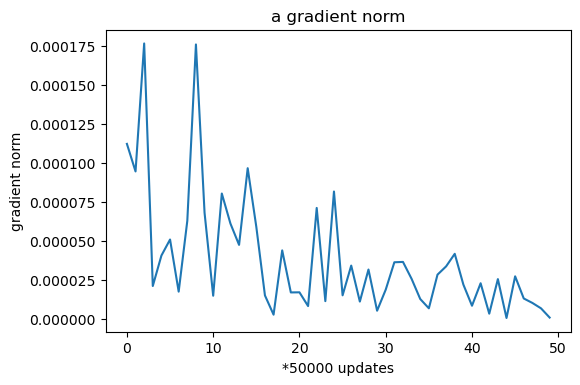

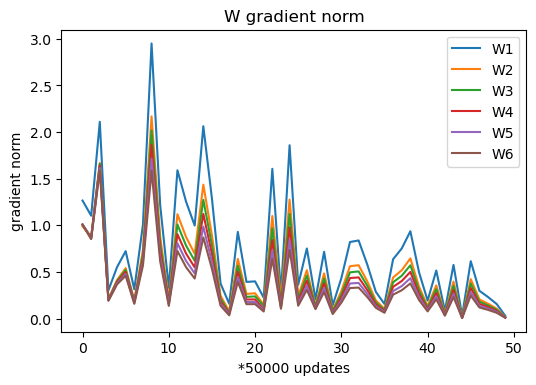

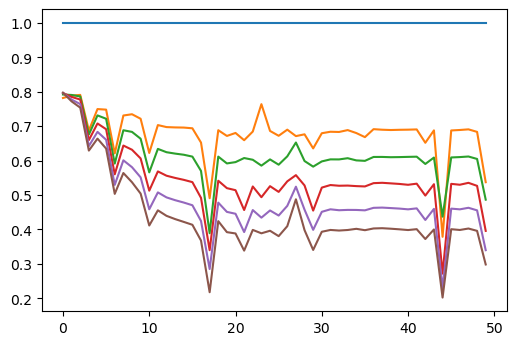

In [76]:
stride_in_steps = data['args'].test_interval * stride
plt.figure()
plt.plot(a_grad_norms)
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('gradient norm')
plt.title('a gradient norm')

plt.figure()
for i in range(net.n_layers):
    plt.plot(grad_norms[i], label='W'+str(i+1))
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('gradient norm')
plt.title('W gradient norm')
plt.legend()

plt.figure()
for i in range(net.n_layers):
    plt.plot(np.array(grad_norms[i]) / np.array(grad_norms[0]), label='W'+str(i+1))

## Fisher info at every layer

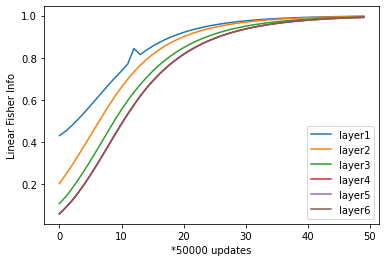

In [27]:
plt.figure()
for i in range(net.n_layers):
    plt.plot(fi_curves[i], label='layer'+str(i+1))
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('Linear Fisher Info')
plt.legend()

## Signal norm
$ \lVert \langle f^l(\theta_+) - f^l(\theta_-) \rangle \rVert $

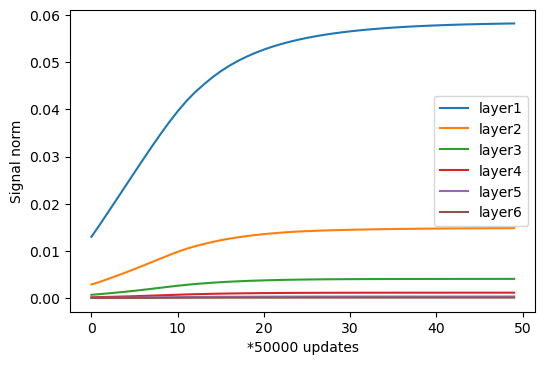

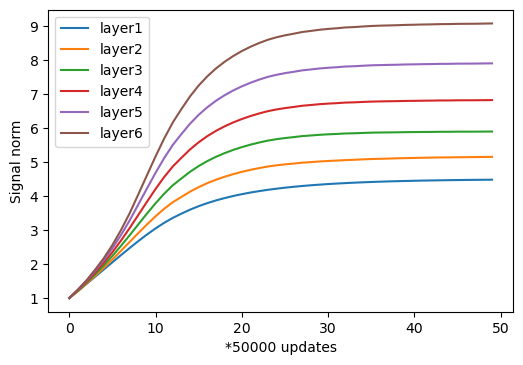

In [79]:
plt.figure()
for i in range(net.n_layers):
    plt.plot(signal_norms[i], label='layer'+str(i+1))
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('Signal norm')
plt.legend()

plt.figure()
for i in range(net.n_layers):
    plt.plot(signal_norms[i] / signal_norms[i][0], label='layer'+str(i+1))
plt.xlabel(f'*{stride_in_steps} updates')
plt.ylabel('Signal norm')
plt.legend()

## Breakdown components of gradients

In [46]:
# create a Model object for loading weight changes; create a Stimuli object for testing
net = model.Model(data['args'])
stim = train_utils.GaborStimuli(data['args'], simple_mode=True, verbose=False)

# number of time points to sample
n_sample = 50
stride = int(len(data['loss']) / n_sample)

prod_norms = np.zeros((net.n_layers, n_sample))

for i in trange(n_sample):
    sampled_loss[i] = data['loss'][stride * i]
    
    # load weight changes
    net.RESET_WEIGHTS()
    for j in range(net.n_layers):
        net.Ws[j] += utils.recover_matrix(data['delW'][j][stride * i])
    
    net.RO.weight.data = torch.from_numpy(data['a'][stride * i]).float().t()
    
    w_effs = r_utils.get_effective_weights(net, stim.x0, full_mat=True)[0]
    
    a1 = data['a'][stride * i] @ matrix_prod(w_effs)
    prod_norms[0, i] = np.linalg.norm(a1) * np.linalg.norm(stim.x1)
    prod_norms[1, i] = np.linalg.norm(data['a'][stride * i] @ matrix_prod(w_effs[:-1])) * np.linalg.norm(w_effs[0] @ stim.x1.numpy().T)
    sL = matrix_prod(w_effs) @ stim.x1.numpy().T
#     prod_norms[1, i] = np.linalg.norm(sL)

100%|██████████| 50/50 [00:13<00:00,  3.60it/s]


In [42]:
def matrix_prod(list_of_mats):
    result = list_of_mats[0]
    for m in list_of_mats[1:]:
        result = m @ result
    return result

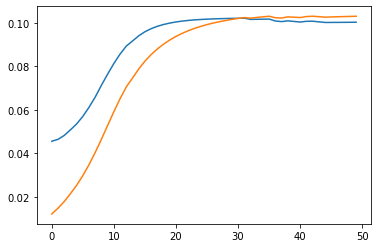

In [47]:
plt.figure()
plt.plot(prod_norms[0])
plt.plot(prod_norms[1])

## Order parameters

In [81]:
data.keys()

dict_keys(['loss', 'error', 'a', 'v_eff', 'x1', 'theta1', 'theta2', 'phi_prime', 'delW', 'args', '_time', 'errors_with_original_readouts', 'errors_with_new_readouts'])

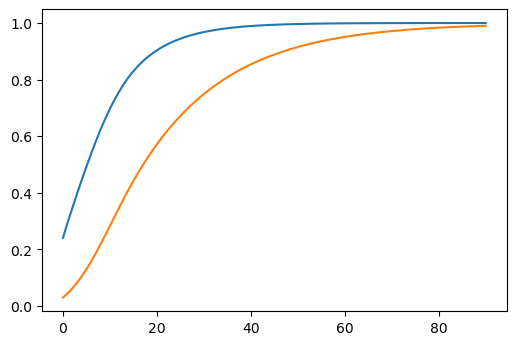

In [85]:
plt.figure()
plt.plot([utils.cos(v, stim.x1) for v in data['v_eff']])
plt.plot([1 - np.sqrt(1 - utils.cos(v, stim.x1)**2) for v in data['v_eff']])

In [43]:
np.arange(5)[:-1]

array([0, 1, 2, 3])

## Noise correlation

In [12]:
data.keys()

dict_keys(['loss', 'error', 'a', 'v_eff', 'x1', 'theta1', 'theta2', 'phi_prime', 'delW', 'args', '_time', 'errors_with_original_readouts', 'errors_with_new_readouts'])

0.2
0.3
1.0
0.19881724
0.1
0.8
0.24095093
0.9
0.2161405
0.5
0.39276284
0.4
0.4890651
0.6
0.32334566
0.7
0.2754996


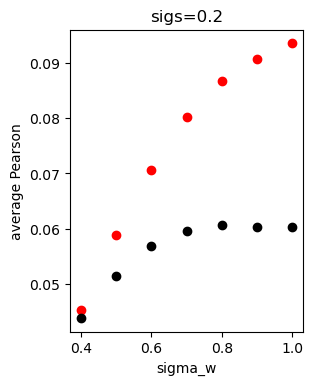

In [11]:
layer_ind = 1
plt.figure(figsize=(3, 4))

for data in dataset:
    print(data['args'].sig_w)
    
    if data['args'].sig_w < 0.4:
        continue
    
    bl_net = model.Model(data['args'])
    stim = train_utils.GaborStimuli(data['args'], simple_mode=True, verbose=False)
    print(utils.cos(data['v_eff'][0], stim.x1))
    
    w_eff_init = r_utils.get_effective_weights(bl_net, stim.x0, full_mat=True)[0]
    utils.load_GD_changes(bl_net, data)
    w_eff_final = r_utils.get_effective_weights(bl_net, stim.x0, full_mat=True)[0]
    plt.scatter(data['args'].sig_w, utils.get_corr_coefs(utils.matrix_prod(w_eff_init, layer_ind + 1)).mean(), color='r')
    plt.scatter(data['args'].sig_w, utils.get_corr_coefs(utils.matrix_prod(w_eff_final, layer_ind + 1)).mean(), color='k')
#     plt.scatter(data['args'].sig_w, np.abs(utils.get_corr_coefs(utils.matrix_prod(w_eff_init, layer_ind + 1))).mean(), color='r')
#     plt.scatter(data['args'].sig_w, np.abs(utils.get_corr_coefs(utils.matrix_prod(w_eff_final, layer_ind + 1))).mean(), color='k')


plt.xlabel('sigma_w')
plt.ylabel('average Pearson')
plt.title('sigs=0.2')
plt.savefig('figures/raw/mean_corr_before_after_sigs_layer2.svg')

In [4]:
print(utils.get_corr_coefs(w_eff_init[0]).mean())
print(utils.get_corr_coefs(w_eff_final[0]).mean())

print(utils.get_corr_coefs(w_eff_init[1] @ w_eff_init[0]).mean())
print(utils.get_corr_coefs(w_eff_final[1] @ w_eff_final[0]).mean())

print(utils.get_corr_coefs(w_eff_init[2] @ w_eff_init[1] @ w_eff_init[0]).mean())
print(utils.get_corr_coefs(w_eff_final[2] @ w_eff_final[1] @ w_eff_final[0]).mean())

0.51913583
0.44604665
0.4704505
0.32701963
0.46088734
0.26288924


(array([  152.,   342.,   506.,   626.,   736.,   812.,   888.,   928.,
          978.,  1022.,  1030.,  1052.,  1078.,  1082.,  1062.,  1082.,
         1092.,  1074.,  1070.,  1084.,  1040.,  1050.,  1052.,  1028.,
         1030.,  1014.,  1004.,  1004.,   994.,   984.,   994.,   946.,
          980.,   942.,   952.,   986.,   920.,   914.,   956.,   916.,
          912.,   912.,   936.,   916.,   882.,   916.,   918.,   914.,
          926.,   876.,   952.,   900.,   922.,   912.,   926.,   922.,
          946.,   924.,   958.,   944.,   960.,   964.,   984.,   976.,
         1002.,   994.,  1032.,  1062.,  1028.,  1078.,  1110.,  1104.,
         1146.,  1140.,  1200.,  1216.,  1228.,  1286.,  1360.,  1358.,
         1412.,  1452.,  1538.,  1582.,  1640.,  1746.,  1838.,  1936.,
         2030.,  2222.,  2312.,  2516.,  2742.,  2996.,  3354.,  3756.,
         4412.,  5354.,  7156., 18187.]),
 array([-0.6620917 , -0.64547074, -0.6288498 , -0.61222893, -0.595608  ,
        -0.57898706, 

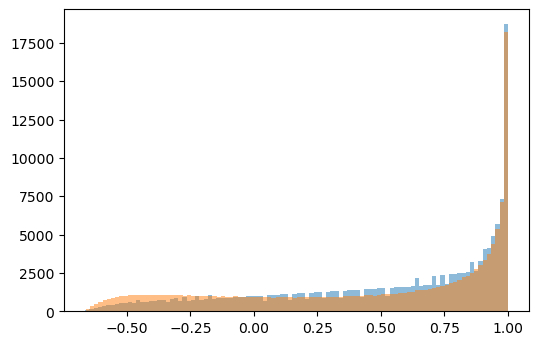

In [149]:

    
plt.figure()
plt.hist(get_corr_coefs(w_eff_init[0]), alpha=0.5, bins=100)
plt.hist(get_corr_coefs(w_eff_final[0]), alpha=0.5, bins=100)    

In [ ]:
plt.figure()
plt.hist((w_eff_init[0] @ w_eff_init[0].T).flatten())
plt.hist((w_eff_final[0] @ w_eff_final[0].T).flatten())
plt.ylim(0, 100000)

plt.figure()
plt.hist((w_eff_init[1] @ w_eff_init[0] @ w_eff_init[0].T @ w_eff_init[1].T).flatten())
plt.hist((w_eff_final[1] @ w_eff_final[0] @ w_eff_final[0].T @ w_eff_final[1].T).flatten())
plt.ylim(0, 100000)

plt.figure()
plt.hist((w_eff_init[2] @ w_eff_init[1] @ w_eff_init[0] @ w_eff_init[0].T @ w_eff_init[1].T @ w_eff_init[2].T).flatten())
plt.hist((w_eff_final[2] @ w_eff_final[1] @ w_eff_final[0] @ w_eff_final[0].T @ w_eff_final[1].T @ w_eff_final[2].T).flatten())
plt.ylim(0, 100000)

In [123]:
Finit = w_eff_init[2] @ w_eff_init[1] @ w_eff_init[0]
Ffinal = w_eff_final[2] @ w_eff_final[1] @ w_eff_final[0]

print(np.linalg.norm(data['a'][0].T @ Finit))
print(np.linalg.norm(data['a'][1].T @ Ffinal))

0.43227872
1.0015029


In [129]:
np.linalg.norm(data['v_eff'][0])

0.9781252

(array([615.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   9.,  98.,  94., 184.]),
 array([0.        , 0.00125883, 0.00251766, 0.00377649, 0.00503533,
        0.00629416, 0.00755299, 0.00881182, 0.01007065, 0.01132949,
        0.01258832, 0.01384715, 0.01510598, 0.01636481, 0.01762364,
        0.01888248, 0.02014131, 0.02140014, 0.02265897, 0.0239178 ,
        0.02517663], dtype=float32),
 <BarContainer object of 20 artists>)

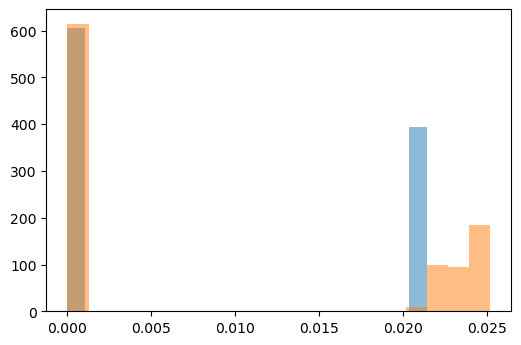

In [172]:
plt.figure()
plt.hist(np.linalg.norm(w_eff_init[0], axis=1), bins=20, alpha=0.5)
plt.hist(np.linalg.norm(w_eff_final[0], axis=1), bins=20, alpha=0.5)